# BUSI Breast Ultrasound Classification (Benign vs Malignant) — VGG16

**Task**: Training Task 2 — a controlled, fair three-way architecture comparison between
ResNet50, VGG16 and DenseNet121 on the same benign/malignant classification problem.

**Fair-comparison design**: this notebook (and its two siblings in `../task2_vgg16/` and
`../task2_densenet121/`) uses the exact same training method — the *only* variable that
differs across the three notebooks is the model architecture:
- **Full fine-tuning**: every layer is trainable, nothing is frozen. The three
  architectures have very different layer structures (ResNet's `layer1..layer4`,
  VGG's `features`/`classifier`, DenseNet's dense blocks), so there is no
  principled way to define an "equivalent" partial-freezing depth across all
  three — full fine-tuning sidesteps that problem entirely.
- **Plain `nn.CrossEntropyLoss()`**: no class weighting, no label smoothing.
- **Checkpoint selection**: best validation **macro F1** (`f1_score(average="macro")`),
  identical across all three notebooks.
- **Identical optimizer, learning rate, batch size, epoch budget, early-stopping
  patience, and `train_sub`/`val`/`test` split** (same `RANDOM_SEED`).

Evaluation metrics are macro-averaged (benign and malignant scored separately, then averaged with equal weight), per the assignment PDF's "across all categories" requirement.


## 1. Configuration

All hyperparameters live here so a re-run only needs edits in one place. Every
value in this cell is identical across the three architecture notebooks.

In [1]:
import os

# ===== Paths =====
DATASET_DIR = os.path.expanduser("~/datasets/BUSI")
TRAIN_XLSX = os.path.join(DATASET_DIR, "train.xlsx")
TEST_XLSX = os.path.join(DATASET_DIR, "test.xlsx")
IMAGES_ROOT = os.path.join(DATASET_DIR, "images")
IMAGE_COL, LABEL_COL = "Image", "Label"

# Placeholder; re-derived from the data in section 3 by cross-checking filenames,
# the same way Task 1 does — never hardcode which numeric label means which class.
LABEL_MAP = {"benign": 0, "malignant": 1}
CLASS_NAMES = ["benign", "malignant"]

# ===== Training hyperparameters — IDENTICAL across resnet50/vgg16/densenet121 =====
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 0  # interactive terminals on this cluster don't have enough /dev/shm for workers>0
RANDOM_SEED = 42

# ===== train/val/test split: identical ratio, seed and stratify column across all
# three notebooks, so train_sub/val/test contain exactly the same images. =====
VAL_SPLIT_RATIO = 0.2

EARLY_STOPPING_PATIENCE = 8

# Checkpoint selection metric: validation macro F1 (benign and malignant F1
# averaged with equal weight) — identical convention used for the final test
# report in section 10.
CHECKPOINT_METRIC = "val_f1_macro"

# No FREEZE_* switch here on purpose: every layer is trainable (full fine-tuning)
# for all three architectures, which is the simplest way to keep the training
# method identical across models whose layer structures aren't comparable
# (ResNet's layer1..4 vs VGG's features/classifier vs DenseNet's dense blocks).

SCHEDULER_TYPE = "cosine"

# ===== Output paths (each Task 2 model keeps its own outputs/ dir) =====
OUTPUT_DIR = os.path.expanduser("~/projects/research_training/task2_vgg16/outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_TAG = "vgg16"

MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_model.pt")
LOSS_CURVE_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_loss_curve.png")
HISTORY_SAVE_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_history.json")
TEST_METRICS_BAR_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_test_metrics.png")
PREDICTIONS_VIZ_PATH = os.path.join(OUTPUT_DIR, f"{MODEL_TAG}_predictions.png")

print("Dataset dir:", DATASET_DIR)
print("Model:", MODEL_TAG)
print("Outputs will be saved to:", OUTPUT_DIR)


Dataset dir: /mnt/cv_data/users/hahaxixi/datasets/BUSI
Model: vgg16
Outputs will be saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs


## 2. Imports

In [2]:
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
from sklearn.model_selection import train_test_split

# Fix every source of randomness so the split and training are reproducible.
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 3. Load data and verify the label mapping

`train.xlsx` / `test.xlsx` store the label as a bare integer (0/1); we cross-check
against the image filenames (which start with "benign" or "malignant") so we never
assume which integer means which class.

In [3]:
train_df = pd.read_excel(TRAIN_XLSX)
test_df = pd.read_excel(TEST_XLSX)
print(f"train.xlsx: {len(train_df)} rows, columns: {list(train_df.columns)}")
print(f"test.xlsx: {len(test_df)} rows, columns: {list(test_df.columns)}")


train.xlsx: 517 rows, columns: ['Image', 'Label']
test.xlsx: 130 rows, columns: ['Image', 'Label']


In [4]:
# ===== Verify what each numeric label actually means, from the filenames themselves =====
combined_df = pd.concat([train_df, test_df], ignore_index=True)
name_from_file = combined_df[IMAGE_COL].astype(str).str.extract(r"^([A-Za-z]+)")[0].str.lower()
label_value = combined_df[LABEL_COL]

check_table = pd.crosstab(label_value, name_from_file)
print("Numeric label vs. filename-derived class name (each numeric id should map to exactly one name):")
print(check_table)

id_to_name = {}
for label_id, row in check_table.iterrows():
    matched_names = row[row > 0].index.tolist()
    assert len(matched_names) == 1, (
        f"Label {label_id} matches multiple class names {matched_names} - "
        f"something is wrong with IMAGE_COL/LABEL_COL or the data itself."
    )
    id_to_name[int(label_id)] = matched_names[0]

# Overwrite the section-1 placeholders with the verified mapping (sorted by label id).
CLASS_NAMES = [id_to_name[i] for i in sorted(id_to_name)]
LABEL_MAP = {name: i for i, name in id_to_name.items()}

print()
print("Verified label meaning:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i} = {name}")
print("CLASS_NAMES:", CLASS_NAMES)
print("LABEL_MAP:", LABEL_MAP)


Numeric label vs. filename-derived class name (each numeric id should map to exactly one name):
0      benign  malignant
Label                   
0           0        210
1         437          0

Verified label meaning:
  0 = malignant
  1 = benign
CLASS_NAMES: ['malignant', 'benign']
LABEL_MAP: {'malignant': 0, 'benign': 1}


## 4. Train / validation / test split

Same ratio, seed and stratify column across all three architecture notebooks, so
`train_sub`, `val` and `test` contain exactly the same images in every one of
them — required for the comparison to be fair.

In [5]:
train_sub_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SPLIT_RATIO,
    stratify=train_df[LABEL_COL],
    random_state=RANDOM_SEED,
)
train_sub_df = train_sub_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"train_sub: {len(train_sub_df)} rows, val: {len(val_df)} rows "
      f"(stratified split of the original {len(train_df)}-row train.xlsx)")
print("train_sub label distribution:")
print(train_sub_df[LABEL_COL].value_counts())
print("val label distribution:")
print(val_df[LABEL_COL].value_counts())

# ===== Leakage check: no image filename should appear in more than one of the three splits =====
train_sub_files = set(train_sub_df[IMAGE_COL])
val_files = set(val_df[IMAGE_COL])
test_files = set(test_df[IMAGE_COL])

assert not (train_sub_files & val_files), "train_sub/val overlap!"
assert not (train_sub_files & test_files), "train_sub/test overlap!"
assert not (val_files & test_files), "val/test overlap!"
print("Leakage check passed: train_sub / val / test share no images.")


train_sub: 413 rows, val: 104 rows (stratified split of the original 517-row train.xlsx)
train_sub label distribution:
Label
1    276
0    137
Name: count, dtype: int64
val label distribution:
Label
1    70
0    34
Name: count, dtype: int64
Leakage check passed: train_sub / val / test share no images.


## 5. Dataset, transforms and DataLoaders

Training images get flip/rotation/color-jitter augmentation (identical across all
three notebooks); val/test only get resize + normalize so evaluation stays
deterministic and comparable.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class BUSIDataset(Dataset):
    """Each sample is (image tensor, integer label)."""

    def __init__(self, df, images_root, image_col, label_col, label_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_root = images_root
        self.image_col = image_col
        self.label_col = label_col
        self.label_map = label_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _to_label_id(self, raw_label):
        if isinstance(raw_label, (int, np.integer)):
            return int(raw_label)
        return self.label_map[str(raw_label).strip().lower()]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_root, str(row[self.image_col]))
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = self._to_label_id(row[self.label_col])
        return image, label


train_dataset = BUSIDataset(train_sub_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=train_transform)
val_dataset = BUSIDataset(val_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)
test_dataset = BUSIDataset(test_df, IMAGES_ROOT, IMAGE_COL, LABEL_COL, LABEL_MAP, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"train_sub: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)} samples")


train_sub: 413, val: 104, test: 130 samples


## 6. Visualize a few training samples

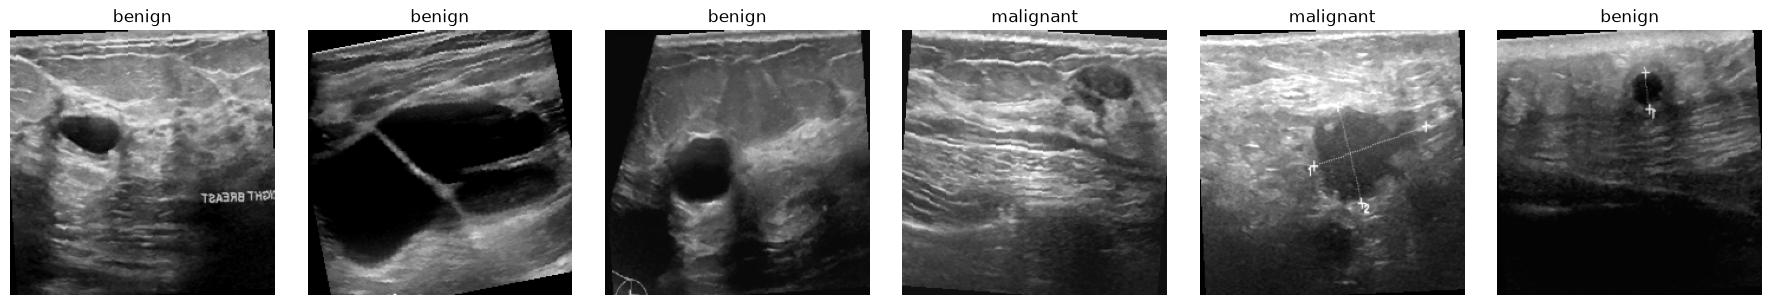

In [7]:
def denormalize(img_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


sample_imgs, sample_labels = next(iter(train_loader))
n_show = min(6, len(sample_imgs))
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1:
    axes = [axes]
for i in range(n_show):
    axes[i].imshow(denormalize(sample_imgs[i]))
    axes[i].set_title(CLASS_NAMES[sample_labels[i].item()])
    axes[i].axis("off")
plt.tight_layout()
plt.show()


## 7. Build the model — VGG16

ImageNet-pretrained VGG16 with its final classifier layer (`model.classifier[6]`,
originally 4096→1000) replaced by a plain `Linear(4096, 2)` (no dropout, to keep
the head as simple as the ResNet50/DenseNet121 heads). **Every parameter is
trainable** — no part of `.features` or `.classifier` is frozen, matching the
full-fine-tuning method used for the other two architectures.

In [8]:
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(CLASS_NAMES))
model = model.to(device)

# Full fine-tuning: nothing is frozen, so every parameter is trainable by default.
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params:,} / total: {total_params:,} "
      f"({trainable_params / total_params:.1%})")
print(model.classifier)


Trainable params: 134,268,738 / total: 134,268,738 (100.0%)
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=2, bias=True)
)


## 8. Loss, optimizer, scheduler

Plain `CrossEntropyLoss()` — no class weighting, no label smoothing — and
`AdamW` over **all** parameters (nothing is frozen), identical across all three
notebooks.

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

if SCHEDULER_TYPE == "cosine":
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
else:
    scheduler = None

print("criterion: CrossEntropyLoss() (no class weight, no label smoothing)")
print(f"optimizer: AdamW(lr={LEARNING_RATE}), all parameters trainable")
print(f"scheduler: {SCHEDULER_TYPE}")


criterion: CrossEntropyLoss() (no class weight, no label smoothing)
optimizer: AdamW(lr=0.0001), all parameters trainable
scheduler: cosine


## 9. Training loop with early stopping

Checkpoint selection uses **macro-averaged** F1 on the validation set (benign and
malignant F1 computed separately, then averaged) — the same convention used for
the final test-set report in section 11.

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, all_preds, all_labels


In [11]:
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1_macro": [], "lr": []}

best_val_f1 = -1.0
best_state = None
best_epoch = None
epochs_no_improve = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
    # Macro F1: benign and malignant F1 averaged with equal weight (not biased
    # toward either class), matching the assignment's "across all categories" ask.
    val_f1_macro = f1_score(val_labels, val_preds, average="macro")
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1_macro"].append(val_f1_macro)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | lr={current_lr:.2e} | train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1_macro={val_f1_macro:.4f}")

    if scheduler is not None:
        scheduler.step()

    if val_f1_macro > best_val_f1:
        best_val_f1 = val_f1_macro
        best_epoch = epoch
        best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
            print(f"val_f1_macro hasn't improved for {EARLY_STOPPING_PATIENCE} epochs, "
                  f"stopping early at epoch {epoch}.")
            break

model.load_state_dict(best_state)
print(f"Loaded the weights with the highest val_f1_macro={best_val_f1:.4f}, from epoch {best_epoch}")
history["best_epoch"] = best_epoch


Epoch 01/20 | lr=1.00e-04 | train_loss=0.6437 | val_loss=0.5956 | val_acc=0.7981 | val_f1_macro=0.7197


Epoch 02/20 | lr=9.94e-05 | train_loss=0.5347 | val_loss=0.9567 | val_acc=0.7115 | val_f1_macro=0.5170


Epoch 03/20 | lr=9.76e-05 | train_loss=0.6312 | val_loss=0.4954 | val_acc=0.7788 | val_f1_macro=0.7506


Epoch 04/20 | lr=9.46e-05 | train_loss=0.5283 | val_loss=0.5635 | val_acc=0.5962 | val_f1_macro=0.5948


Epoch 05/20 | lr=9.05e-05 | train_loss=0.5342 | val_loss=0.5135 | val_acc=0.7885 | val_f1_macro=0.6930


...

Epoch 16/20 | lr=1.46e-05 | train_loss=0.1064 | val_loss=0.3752 | val_acc=0.7885 | val_f1_macro=0.7803


Epoch 17/20 | lr=9.55e-06 | train_loss=0.1044 | val_loss=0.3487 | val_acc=0.8269 | val_f1_macro=0.8172


Epoch 18/20 | lr=5.45e-06 | train_loss=0.0770 | val_loss=0.3487 | val_acc=0.8462 | val_f1_macro=0.8359


Epoch 19/20 | lr=2.45e-06 | train_loss=0.0800 | val_loss=0.3383 | val_acc=0.8558 | val_f1_macro=0.8453


Epoch 20/20 | lr=6.16e-07 | train_loss=0.0746 | val_loss=0.3402 | val_acc=0.8558 | val_f1_macro=0.8453
Loaded the weights with the highest val_f1_macro=0.8725, from epoch 13


## 10. Plot the loss curve

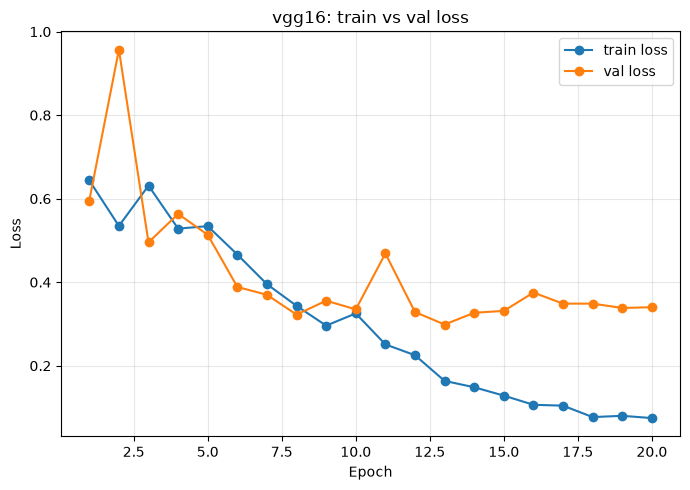

Loss curve saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_loss_curve.png


Per-epoch history saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_history.json


In [12]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, history["train_loss"], marker="o", label="train loss")
ax.plot(epochs_range, history["val_loss"], marker="o", label="val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"{MODEL_TAG}: train vs val loss")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(LOSS_CURVE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Loss curve saved to:", LOSS_CURVE_PATH)

with open(HISTORY_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("Per-epoch history saved to:", HISTORY_SAVE_PATH)


## 11. Test-set evaluation (macro-averaged metrics)

The test set is untouched until this single, final evaluation — training and
checkpoint selection only ever looked at `val`. Metrics are macro-averaged
(`average="macro"`), per the assignment's "across all categories" requirement,
not a single positive-class convention.

Test Accuracy       : 0.8615
Precision (macro)   : 0.8352
Recall (macro)      : 0.8352
F1 (macro)          : 0.8352

Confusion matrix (rows = true label, columns = predicted label):
[[30  9]
 [ 9 82]]

Per-class breakdown:
              precision    recall  f1-score   support

   malignant       0.77      0.77      0.77        39
      benign       0.90      0.90      0.90        91

    accuracy                           0.86       130
   macro avg       0.84      0.84      0.84       130
weighted avg       0.86      0.86      0.86       130



Test metrics appended to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_history.json


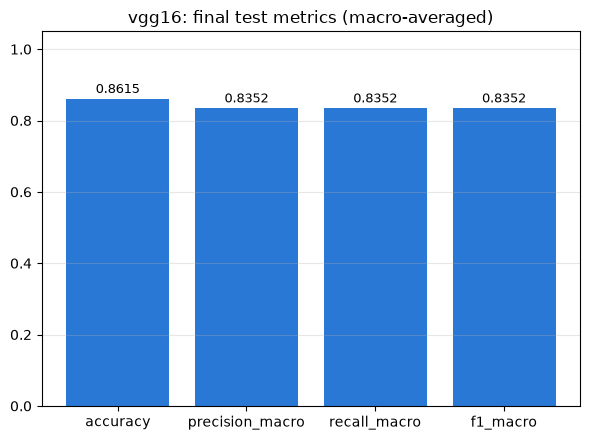

Test metrics bar chart saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_test_metrics.png


In [13]:
final_loss, final_acc, final_preds, final_labels = evaluate(model, test_loader, criterion, device)

precision_macro = precision_score(final_labels, final_preds, average="macro")
recall_macro = recall_score(final_labels, final_preds, average="macro")
f1_macro = f1_score(final_labels, final_preds, average="macro")
cm = confusion_matrix(final_labels, final_preds)
report_str = classification_report(final_labels, final_preds, target_names=CLASS_NAMES)
report_dict = classification_report(final_labels, final_preds, target_names=CLASS_NAMES, output_dict=True)

print(f"Test Accuracy       : {final_acc:.4f}")
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall (macro)      : {recall_macro:.4f}")
print(f"F1 (macro)          : {f1_macro:.4f}")
print()
print("Confusion matrix (rows = true label, columns = predicted label):")
print(cm)
print()
print("Per-class breakdown:")
print(report_str)

history["test_accuracy"] = float(final_acc)
history["test_precision_macro"] = float(precision_macro)
history["test_recall_macro"] = float(recall_macro)
history["test_f1_macro"] = float(f1_macro)
history["classification_report"] = report_dict
with open(HISTORY_SAVE_PATH, "w") as f:
    json.dump(history, f, indent=2)
print("Test metrics appended to:", HISTORY_SAVE_PATH)

# ===== Bar chart of the four headline test metrics =====
fig, ax = plt.subplots(figsize=(6, 4.5))
metric_names = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
bars = ax.bar(metric_names, [final_acc, precision_macro, recall_macro, f1_macro], color="#2a78d6")
for b in bars:
    h = b.get_height()
    ax.annotate(f"{h:.4f}", xy=(b.get_x() + b.get_width() / 2, h), xytext=(0, 4),
                textcoords="offset points", ha="center", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title(f"{MODEL_TAG}: final test metrics (macro-averaged)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(TEST_METRICS_BAR_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Test metrics bar chart saved to:", TEST_METRICS_BAR_PATH)


## 12. Visualize test predictions

Every test image with its true label and predicted label; mispredictions are
titled in red.

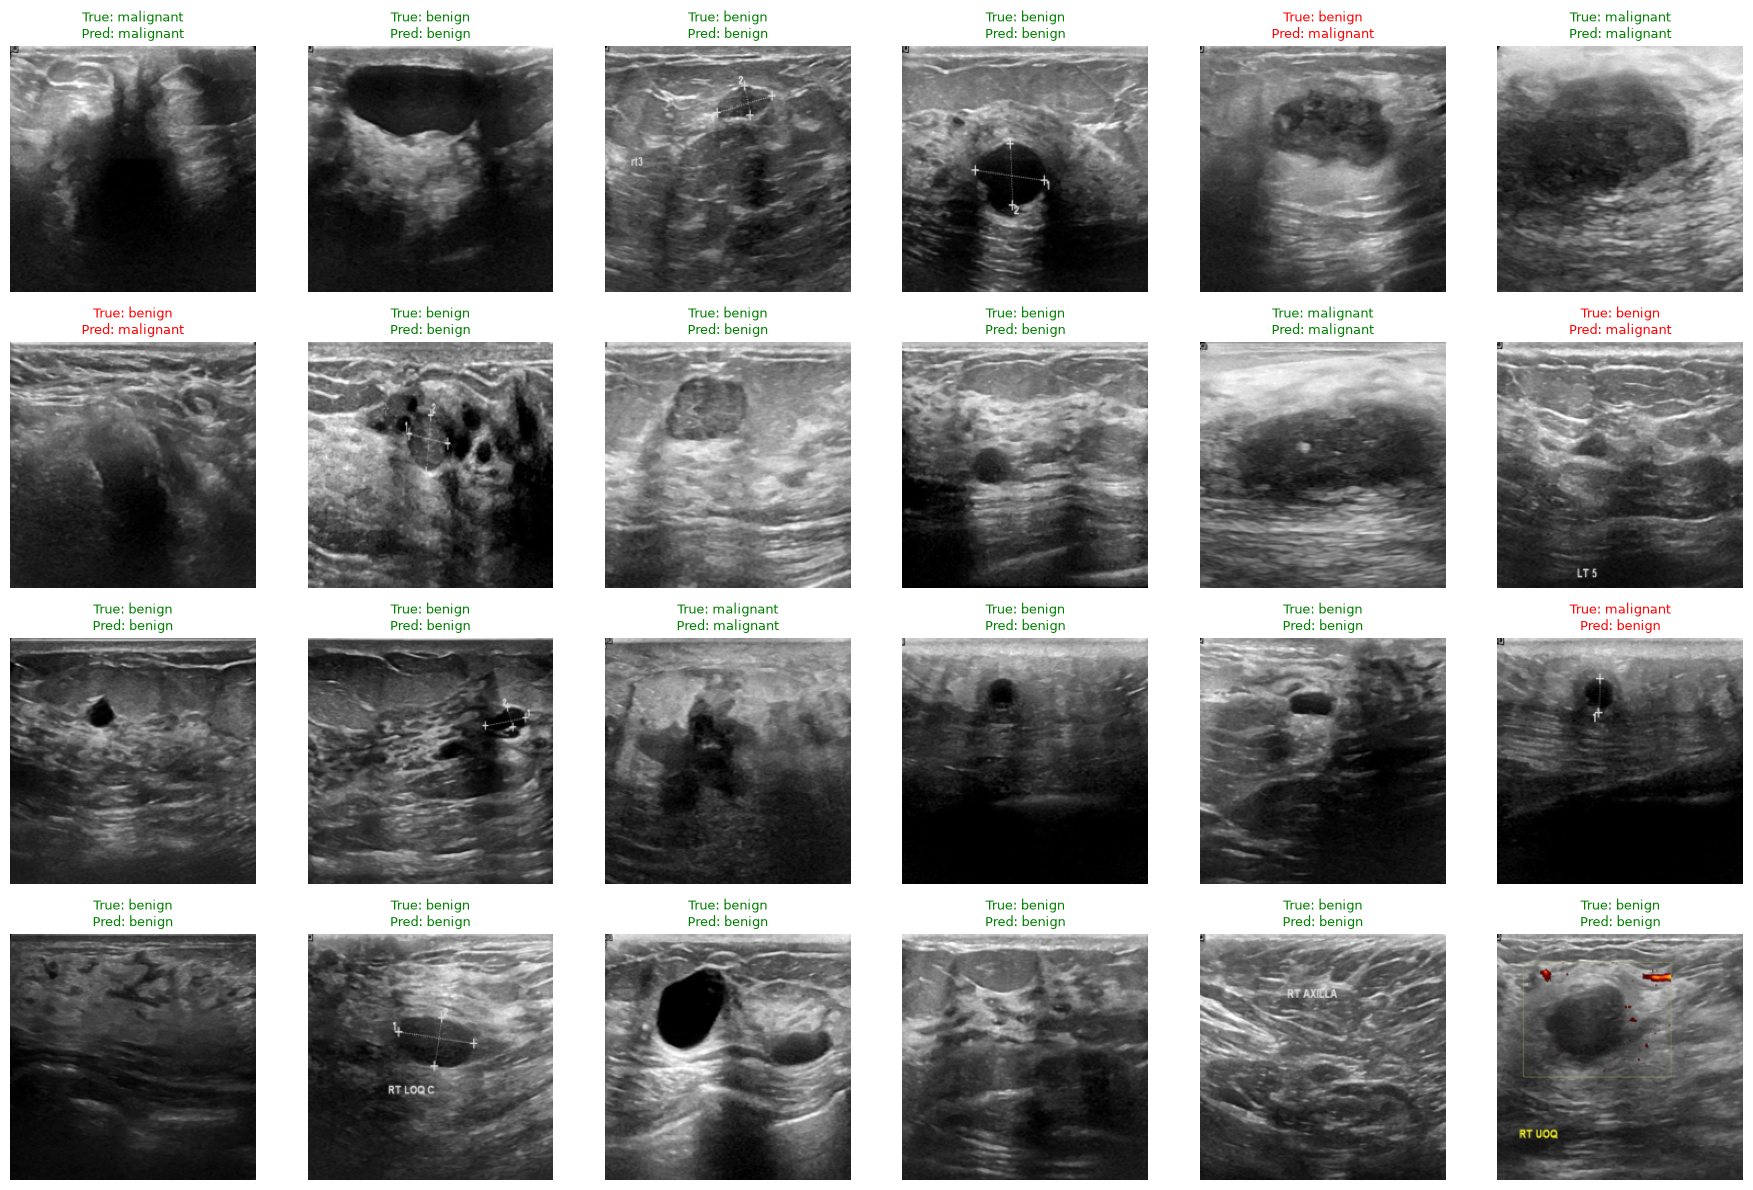

Prediction visualization saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_predictions.png


In [14]:
MAX_IMAGES_TO_SHOW = 24  # set to len(test_dataset) to see all of them

model.eval()
n_show = min(MAX_IMAGES_TO_SHOW, len(test_dataset))
n_cols = 6
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
axes = np.array(axes).reshape(-1)

with torch.no_grad():
    for i in range(n_show):
        image, true_label = test_dataset[i]
        output = model(image.unsqueeze(0).to(device))
        pred_label = output.argmax(dim=1).item()

        ax = axes[i]
        ax.imshow(denormalize(image))
        title = f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}"
        ax.set_title(title, color=("green" if pred_label == true_label else "red"), fontsize=9)
        ax.axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
fig.savefig(PREDICTIONS_VIZ_PATH, dpi=150, bbox_inches="tight")
plt.show()
print("Prediction visualization saved to:", PREDICTIONS_VIZ_PATH)


## 13. Save the model

In [15]:
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print("Model saved to:", MODEL_SAVE_PATH)


Model saved to: /mnt/cv_data/users/hahaxixi/projects/research_training/task2_vgg16/outputs/vgg16_model.pt
